# Identical Machine Job Scheduling

## Environmnet setup

In [28]:
from build_instances import InstanceHandler, UniformInstance, SmallBigInstance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

folder_path_output = "./output"
folder_path_instances = "./instances/identical_job_scheduling"

instance_handler = InstanceHandler(folder_path_instances)

## Analysis

### Single instance

In [29]:
instance = UniformInstance(100, 10, 1, 1000, 42)
# instance = UniformInstance(100, 20, 1, 99, 45)
# instance = SmallBigInstance(900, 1, 9, 100, 80, 99, 150, 63)
epsilon = 0.005

n_jobs, n_machines, processing_times, OPT_exact = instance_handler.fetch(instance, False)

instance_name = instance.filename().replace(".txt", "")

Normalization

In [30]:
# T_opt = max(max(processing_times), sum(processing_times) / n_machines)
T_opt = sum(processing_times) / n_machines
normalized_processing_times = np.array(processing_times) / T_opt

Picking epsilon

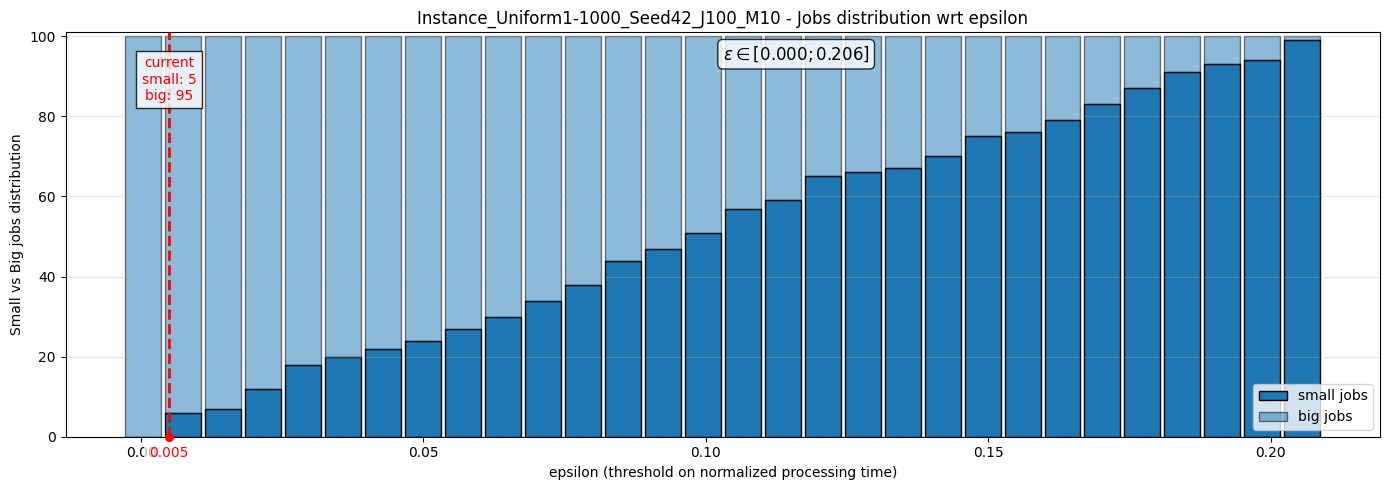

In [31]:
epsilon_min, epsilon_max = min(normalized_processing_times), max(normalized_processing_times)

epsilon_values = np.linspace(epsilon_min, epsilon_max, 30)
small_counts = np.array([(normalized_processing_times < e).sum() for e in epsilon_values])
big_counts = n_jobs - small_counts

plt.figure(figsize=(14, 5))
width = (epsilon_values[1] - epsilon_values[0]) * 0.9

# Plot small vs big jobs distribution wrt epsilon
plt.bar(epsilon_values, small_counts, width=width,  color='C0', edgecolor='k', label='small jobs')
plt.bar(epsilon_values, big_counts, width=width, bottom=small_counts, alpha=0.5, color='C0', edgecolor='k', label='big jobs')
plt.xlabel('epsilon (threshold on normalized processing time)')
plt.ylabel('Small vs Big jobs distribution')
plt.title(f"{instance_name} - Jobs distribution wrt epsilon")
plt.ylim(0, n_jobs + 1)
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Add annotation for big and small jobs
ax = plt.gca()
annotation_epsilon_range = f"$\epsilon \in [{epsilon_min:.3f}; {epsilon_max:.3f}]$"

ax.text(0.5, 0.97, annotation_epsilon_range, transform=ax.transAxes,
  fontsize=12, verticalalignment='top',
  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# highlight current epsilon and show its counts
plt.axvline(epsilon, color='red', linestyle='--', linewidth=2, label=f'epsilon = {epsilon:.3f}')
curr_small = int((normalized_processing_times < epsilon).sum())
curr_big = n_jobs - curr_small
plt.text(epsilon, n_jobs*0.95, f"current\nsmall: {curr_small}\nbig: {curr_big}",
     color='red', ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8))
current_ax = plt.gca()
# red marker on the x-axis at the current epsilon
current_ax.scatter([epsilon], [0], color='red', s=30, zorder=10, clip_on=False)
# current epsilon label below the x-axis highlighted in red
current_ax.text(epsilon, -0.022, f"{epsilon:.3f}", color='red', ha='center', va='top',
                    transform=current_ax.get_xaxis_transform(), fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

Processing times distribution

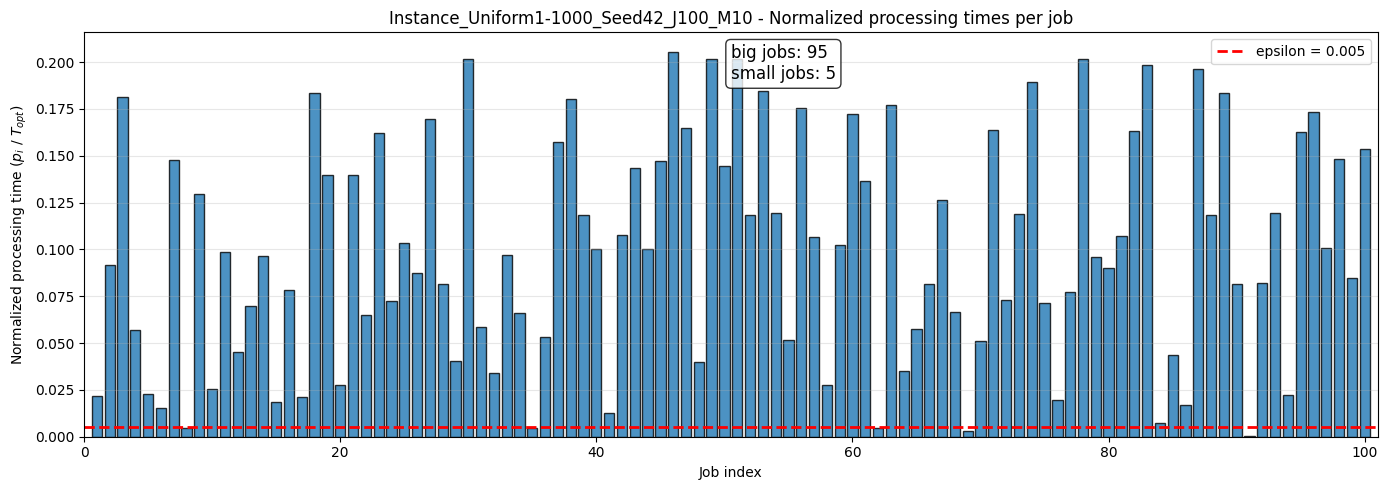

In [32]:
plt.figure(figsize=(14, 5))

# Plot normalized processing times
x = np.arange(1, n_jobs + 1)
plt.bar(x, normalized_processing_times, color='C0', edgecolor='k', alpha=0.8)
plt.xlabel('Job index')
plt.ylabel('Normalized processing time ($p_i$ / $T_{opt}$)')
plt.title(f"{instance_name} - Normalized processing times per job")
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, n_jobs+1)
plt.tight_layout()

# Plot epsilon threshold
plt.axhline(epsilon, color='red', linestyle='--', linewidth=2, label=f'epsilon = {epsilon:.3f}')
plt.legend()

# Add annotation for big and small jobs
ax = plt.gca()
small = int((normalized_processing_times < epsilon).sum())
big = int((normalized_processing_times >= epsilon).sum())
annotation_jobs = f"big jobs: {big}\nsmall jobs: {small}"

ax.text(0.5, 0.97, annotation_jobs, transform=ax.transAxes,
  fontsize=12, verticalalignment='top',
  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

results analysis

In [33]:
df_results = pd.read_csv(f"{folder_path_output}/latest_identical_job_scheduling_random_instances.csv")
df_results

,instance,epsilon_range,n_machines,n_jobs,epsilon,branching_rule,node_selection,profiling_mode,rounding_rule,lower_bound,best_solution,nodes_to_best_solution,nodes_explored,runtime,opt_gap,terminate,best_bound,depth,number_of_nodes_for_optimality,optimal_solution
0,Uniform1-5000_Seed1_J25_M10,"[0.025332, 0.832460]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6180,107,2001,1.155543,0.073786,False,5724.000000,11,-1,5724.000000
1,Uniform1-5000_Seed1_J25_M10,"[0.025332, 0.832460]",10,25,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,5980,48,48,0.024122,0.042809,True,5980.000000,15,-1,5724.000000
2,Uniform1-5000_Seed7_J25_M10,"[0.060725, 0.691370]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6760,176,2001,0.902826,0.045074,False,6455.300000,20,-1,6455.300000
3,Uniform1-5000_Seed7_J25_M10,"[0.060725, 0.691370]",10,25,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,6778,363,2001,0.787205,0.047610,False,6498.000000,20,-1,6455.300000
4,Uniform1-5000_Seed13_J25_M10,"[0.002429, 1.000000]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,5093,438,2001,0.955980,0.033261,False,4940.000000,16,-1,4923.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Uniform1-5000_Seed13_J500_M175,"[0.001627, 0.675907]",175,500,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,8260,444,2001,2159.739494,0.107110,False,7375.274286,350,-1,7375.274286
192,Uniform1-5000_Seed1_J500_M200,"[0.002608, 0.814811]",200,500,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6395,884,2001,2278.210128,0.040823,False,6133.940000,456,-1,6133.940000
193,Uniform1-5000_Seed1_J500_M200,"[0.002608, 0.814811]",200,500,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,6733,623,2001,2630.973438,0.088974,False,6133.940000,400,-1,6133.940000
194,Uniform1-5000_Seed7_J500_M200,"[0.000964, 0.801822]",200,500,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6484,1499,2001,2295.729132,0.039625,False,6227.070000,452,-1,6227.070000


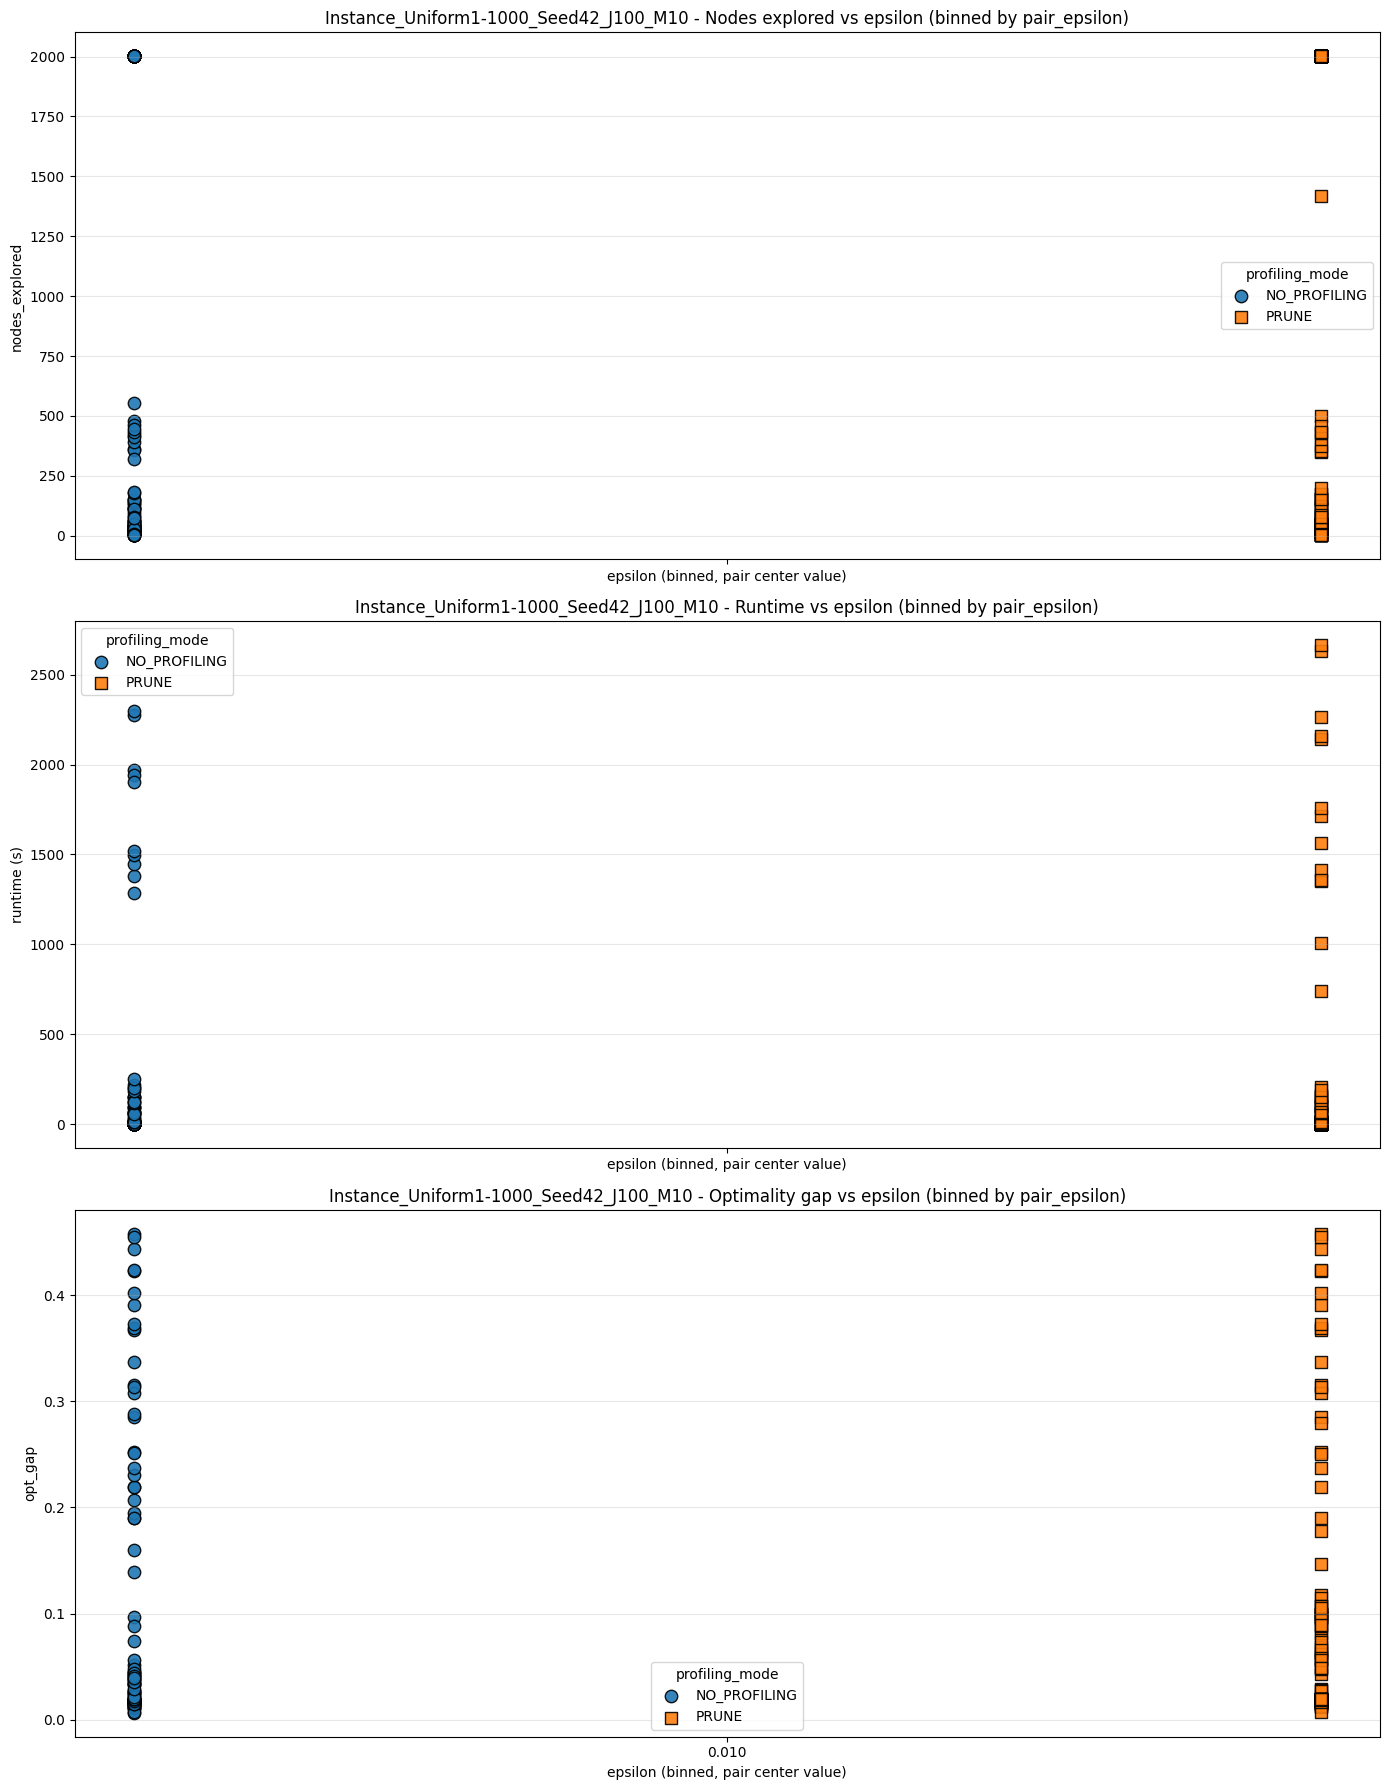

In [34]:
# two-panel scatter: left = nodes_explored, right = runtime
df = df_results.reset_index(drop=True).copy()
df['pair'] = (df.index // 2)
pair_eps = df.iloc[1::2]['epsilon'].reset_index(drop=True)
df['pair_epsilon'] = df['pair'].map(pair_eps)

# bin centers / edges (same logic as before)
bin_centers = pair_eps.values
edges = np.empty(len(bin_centers) + 1, dtype=float)
if len(bin_centers) > 1:
  edges[1:-1] = (bin_centers[:-1] + bin_centers[1:]) / 2
  edges[0] = bin_centers[0] - (bin_centers[1] - bin_centers[0]) / 2
  edges[-1] = bin_centers[-1] + (bin_centers[-1] - bin_centers[-2]) / 2
else:
  delta = 1e-6
  edges[0] = bin_centers[0] - delta
  edges[1] = bin_centers[0] + delta

df['epsilon_bin'] = np.digitize(df['pair_epsilon'], edges) - 1

modes_unique = df['profiling_mode'].unique()
n_modes = len(modes_unique)
marker_list = ['o','s','^','D','P','X','*']
colors_map = plt.cm.tab10(np.linspace(0, 1, max(10, n_modes)))[:n_modes]
bin_offsets = np.linspace(-0.05, 0.05, n_modes)

fig, (ax_nodes, ax_time, ax_opt) = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for i, mode in enumerate(modes_unique):
  df_m = df[df['profiling_mode'] == mode]
  x = df_m['epsilon_bin'].values + bin_offsets[i]
  ax_nodes.scatter(x, df_m['nodes_explored'].values,
           label=mode, marker=marker_list[i % len(marker_list)],
           color=colors_map[i], edgecolor='k', s=80, alpha=0.9)
  ax_time.scatter(x, df_m['runtime'].values,
          label=mode, marker=marker_list[i % len(marker_list)],
          color=colors_map[i], edgecolor='k', s=80, alpha=0.9)
  ax_opt.scatter(x, df_m['opt_gap'].values,
          label=mode, marker=marker_list[i % len(marker_list)],
          color=colors_map[i], edgecolor='k', s=80, alpha=0.9)

# nodes explored plot
ax_nodes.set_xlabel('epsilon (binned, pair center value)')
ax_nodes.set_ylabel('nodes_explored')
ax_nodes.set_title(f"{instance_name} - Nodes explored vs epsilon (binned by pair_epsilon)")
ax_nodes.grid(axis='y', alpha=0.3)
ax_nodes.legend(title='profiling_mode')

# runtime plot
ax_time.set_xlabel('epsilon (binned, pair center value)')
ax_time.set_ylabel('runtime (s)')
ax_time.set_title(f"{instance_name} - Runtime vs epsilon (binned by pair_epsilon)")
ax_time.grid(axis='y', alpha=0.3)
ax_time.legend(title='profiling_mode')

# optimality gap plot
ax_opt.set_xlabel('epsilon (binned, pair center value)')
ax_opt.set_ylabel('opt_gap')
ax_opt.set_title(f"{instance_name} - Optimality gap vs epsilon (binned by pair_epsilon)")
ax_opt.grid(axis='y', alpha=0.3)
ax_opt.legend(title='profiling_mode')

# show only bins that actually contain points, label ticks with pair centers
used_bins = np.sort(df['epsilon_bin'].unique())
xticks = used_bins
xtick_labels = [f"{bin_centers[b-1]:.3f}" for b in used_bins]
ax_nodes.set_xticks(xticks)
ax_nodes.set_xticklabels(xtick_labels, rotation=45)
ax_time.set_xticks(xticks)
ax_time.set_xticklabels(xtick_labels, rotation=45)

plt.tight_layout()
plt.show()

In [35]:
df

,instance,epsilon_range,n_machines,n_jobs,epsilon,branching_rule,node_selection,profiling_mode,rounding_rule,lower_bound,...,runtime,opt_gap,terminate,best_bound,depth,number_of_nodes_for_optimality,optimal_solution,pair,pair_epsilon,epsilon_bin
0,Uniform1-5000_Seed1_J25_M10,"[0.025332, 0.832460]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,1.155543,0.073786,False,5724.000000,11,-1,5724.000000,0,0.01,98
1,Uniform1-5000_Seed1_J25_M10,"[0.025332, 0.832460]",10,25,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,0.024122,0.042809,True,5980.000000,15,-1,5724.000000,0,0.01,98
2,Uniform1-5000_Seed7_J25_M10,"[0.060725, 0.691370]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.902826,0.045074,False,6455.300000,20,-1,6455.300000,1,0.01,98
3,Uniform1-5000_Seed7_J25_M10,"[0.060725, 0.691370]",10,25,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,0.787205,0.047610,False,6498.000000,20,-1,6455.300000,1,0.01,98
4,Uniform1-5000_Seed13_J25_M10,"[0.002429, 1.000000]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,0.955980,0.033261,False,4940.000000,16,-1,4923.600000,2,0.01,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Uniform1-5000_Seed13_J500_M175,"[0.001627, 0.675907]",175,500,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,2159.739494,0.107110,False,7375.274286,350,-1,7375.274286,95,0.01,98
192,Uniform1-5000_Seed1_J500_M200,"[0.002608, 0.814811]",200,500,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,2278.210128,0.040823,False,6133.940000,456,-1,6133.940000,96,0.01,98
193,Uniform1-5000_Seed1_J500_M200,"[0.002608, 0.814811]",200,500,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,...,2630.973438,0.088974,False,6133.940000,400,-1,6133.940000,96,0.01,98
194,Uniform1-5000_Seed7_J500_M200,"[0.000964, 0.801822]",200,500,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,...,2295.729132,0.039625,False,6227.070000,452,-1,6227.070000,97,0.01,98


In [36]:
# display even rows (0-based: rows 0,2,4,...)
df.iloc[1::2]['epsilon']

1      0.01
3      0.01
5      0.01
7      0.01
9      0.01
       ... 
187    0.01
189    0.01
191    0.01
193    0.01
195    0.01
Name: epsilon, Length: 98, dtype: float64

### Multiple instances

In [37]:
filename_resutls = "latest_identical_job_scheduling_random_instances.csv"

max_nodes = 2_000

df_results = pd.read_csv(f"{folder_path_output}/{filename_resutls}")
df_results

,instance,epsilon_range,n_machines,n_jobs,epsilon,branching_rule,node_selection,profiling_mode,rounding_rule,lower_bound,best_solution,nodes_to_best_solution,nodes_explored,runtime,opt_gap,terminate,best_bound,depth,number_of_nodes_for_optimality,optimal_solution
0,Uniform1-5000_Seed1_J25_M10,"[0.025332, 0.832460]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6180,107,2001,1.155543,0.073786,False,5724.000000,11,-1,5724.000000
1,Uniform1-5000_Seed1_J25_M10,"[0.025332, 0.832460]",10,25,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,5980,48,48,0.024122,0.042809,True,5980.000000,15,-1,5724.000000
2,Uniform1-5000_Seed7_J25_M10,"[0.060725, 0.691370]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6760,176,2001,0.902826,0.045074,False,6455.300000,20,-1,6455.300000
3,Uniform1-5000_Seed7_J25_M10,"[0.060725, 0.691370]",10,25,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,6778,363,2001,0.787205,0.047610,False,6498.000000,20,-1,6455.300000
4,Uniform1-5000_Seed13_J25_M10,"[0.002429, 1.000000]",10,25,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,5093,438,2001,0.955980,0.033261,False,4940.000000,16,-1,4923.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Uniform1-5000_Seed13_J500_M175,"[0.001627, 0.675907]",175,500,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,8260,444,2001,2159.739494,0.107110,False,7375.274286,350,-1,7375.274286
192,Uniform1-5000_Seed1_J500_M200,"[0.002608, 0.814811]",200,500,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6395,884,2001,2278.210128,0.040823,False,6133.940000,456,-1,6133.940000
193,Uniform1-5000_Seed1_J500_M200,"[0.002608, 0.814811]",200,500,0.01,max_proc,lowest_lower_bound,PRUNE,all_to_shortest,greedy,6733,623,2001,2630.973438,0.088974,False,6133.940000,400,-1,6133.940000
194,Uniform1-5000_Seed7_J500_M200,"[0.000964, 0.801822]",200,500,0.02,max_proc,lowest_lower_bound,NO_PROFILING,all_to_shortest,greedy,6484,1499,2001,2295.729132,0.039625,False,6227.070000,452,-1,6227.070000


In [38]:
instance_name = df_results['instance'].str.split('_').str[0].unique()[0]

In [39]:
df_results.columns

Index(['instance', 'epsilon_range', 'n_machines', 'n_jobs', 'epsilon',
       'branching_rule', 'node_selection', 'profiling_mode', 'rounding_rule',
       'lower_bound', 'best_solution', 'nodes_to_best_solution',
       'nodes_explored', 'runtime', 'opt_gap', 'terminate', 'best_bound',
       'depth', 'number_of_nodes_for_optimality', 'optimal_solution'],
      dtype='object')

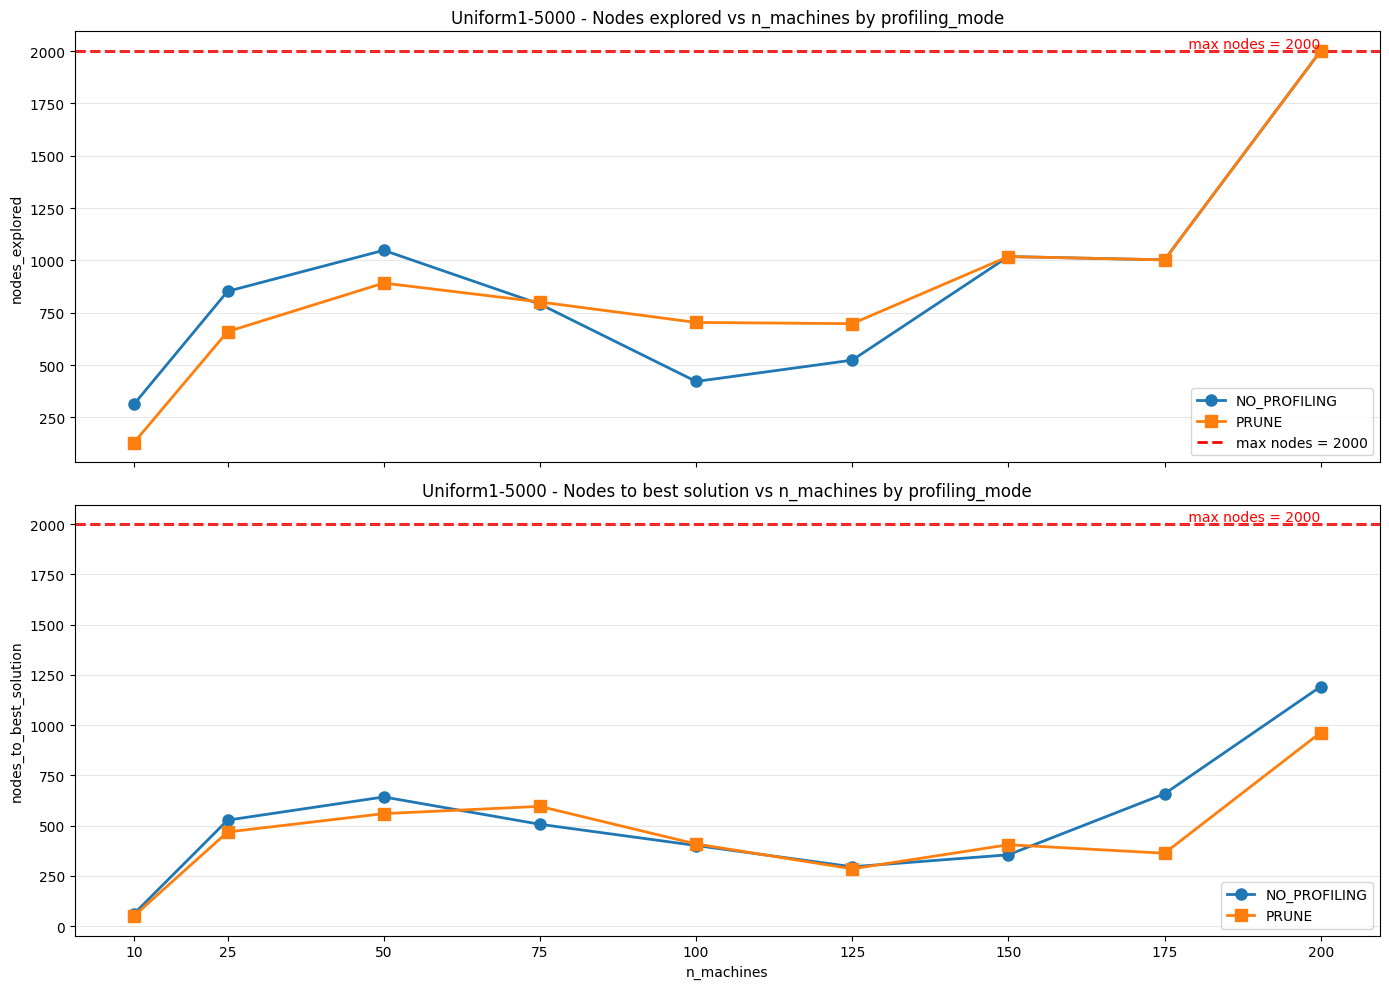

In [40]:
# two-panel: top = nodes_explored, bottom = nodes_to_best_solution
df_nodes = df_results.groupby(['n_machines', 'profiling_mode'])['nodes_explored'].mean().reset_index()
df_nodes_pivot = df_nodes.pivot(index='n_machines', columns='profiling_mode', values='nodes_explored').sort_index()

df_best = df_results.groupby(['n_machines', 'profiling_mode'])['nodes_to_best_solution'].mean().reset_index()
df_best_pivot = df_best.pivot(index='n_machines', columns='profiling_mode', values='nodes_to_best_solution').sort_index()

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# top: nodes_explored
for i, mode in enumerate(df_nodes_pivot.columns):
  ax_top.plot(df_nodes_pivot.index, df_nodes_pivot[mode].values,
              label=mode,
              marker=marker_list[i % len(marker_list)],
              color=colors_map[i % len(colors_map)],
              linewidth=2, markersize=8)

# draw horizontal max_nodes line on top plot
ax_top.axhline(max_nodes, color='red', linestyle='--', linewidth=2, label=f'max nodes = {max_nodes}', zorder=0)
ymin, ymax = ax_top.get_ylim()
if ymax < max_nodes:
  ax_top.set_ylim(ymin, max_nodes * 1.05)

ax_top.text(df_nodes_pivot.index.max(), max_nodes, f' max nodes = {max_nodes}', color='red', va='bottom', ha='right', fontsize=10)
ax_top.set_ylabel('nodes_explored')
ax_top.set_title(f"{instance_name[:29]} - Nodes explored vs n_machines by profiling_mode")
ax_top.grid(axis='y', alpha=0.3)
ax_top.legend()

# bottom: nodes_to_best_solution
for i, mode in enumerate(df_best_pivot.columns):
  ax_bot.plot(df_best_pivot.index, df_best_pivot[mode].values,
              label=mode,
              marker=marker_list[i % len(marker_list)],
              color=colors_map[i % len(colors_map)],
              linewidth=2, markersize=8)

# draw horizontal max_nodes line on bottom plot
ax_bot.axhline(max_nodes, color='red', linestyle='--', linewidth=2, zorder=0)
ymin_b, ymax_b = ax_bot.get_ylim()
if ymax_b < max_nodes:
  ax_bot.set_ylim(ymin_b, max_nodes * 1.05)
if ymin_b > max_nodes:
  ax_bot.set_ylim(max_nodes * 0.95, ymax_b)

ax_bot.text(df_best_pivot.index.max(), max_nodes, f' max nodes = {max_nodes}', color='red', va='bottom', ha='right', fontsize=10)
ax_bot.set_xlabel('n_machines')
ax_bot.set_ylabel('nodes_to_best_solution')
ax_bot.set_title(f"{instance_name[:29]} - Nodes to best solution vs n_machines by profiling_mode")
ax_bot.grid(axis='y', alpha=0.3)
ax_bot.set_xticks(df_nodes_pivot.index)
ax_bot.legend()

plt.tight_layout()
plt.show()

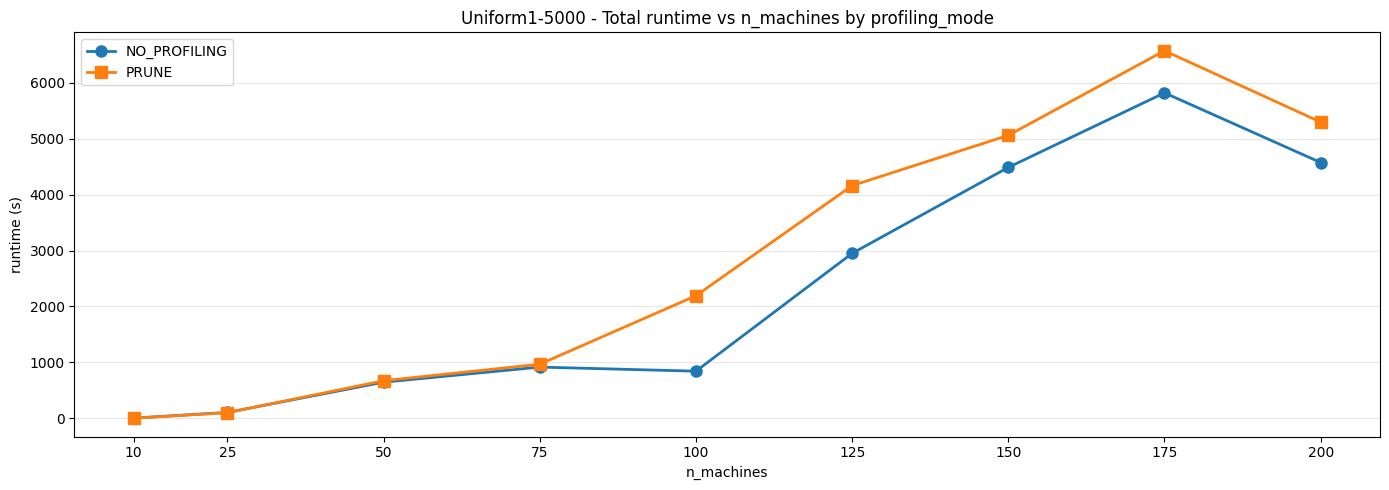

In [41]:
# line plot: n_machines (x) vs runtime (y) for each profiling_mode
df_plot = df_results.groupby(['n_machines', 'profiling_mode'])['runtime'].sum().reset_index()
df_pivot = df_plot.pivot(index='n_machines', columns='profiling_mode', values='runtime').sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
for i, mode in enumerate(df_pivot.columns):
  ax.plot(df_pivot.index, df_pivot[mode].values,
      label=mode,
      marker=marker_list[i % len(marker_list)],
      color=colors_map[i % len(colors_map)],
      linewidth=2, markersize=8)

ax.set_xlabel('n_machines')
ax.set_ylabel('runtime (s)')
ax.set_title(f"{instance_name[:29]} - Total runtime vs n_machines by profiling_mode")
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(df_pivot.index)
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\Tiziano\AppData\Local\Temp\ipykernel_40420\840009562.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im.set_cmap(plt.cm.get_cmap('hot_r'))
C:\Users\Tiziano\AppData\Local\Temp\ipykernel_40420\840009562.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im.set_cmap(plt.cm.get_cmap('hot_r'))
C:\Users\Tiziano\AppData\Local\Temp\ipykernel_40420\840009562.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im.set_cmap(plt.cm.get_cmap('hot_r'))
C:\User

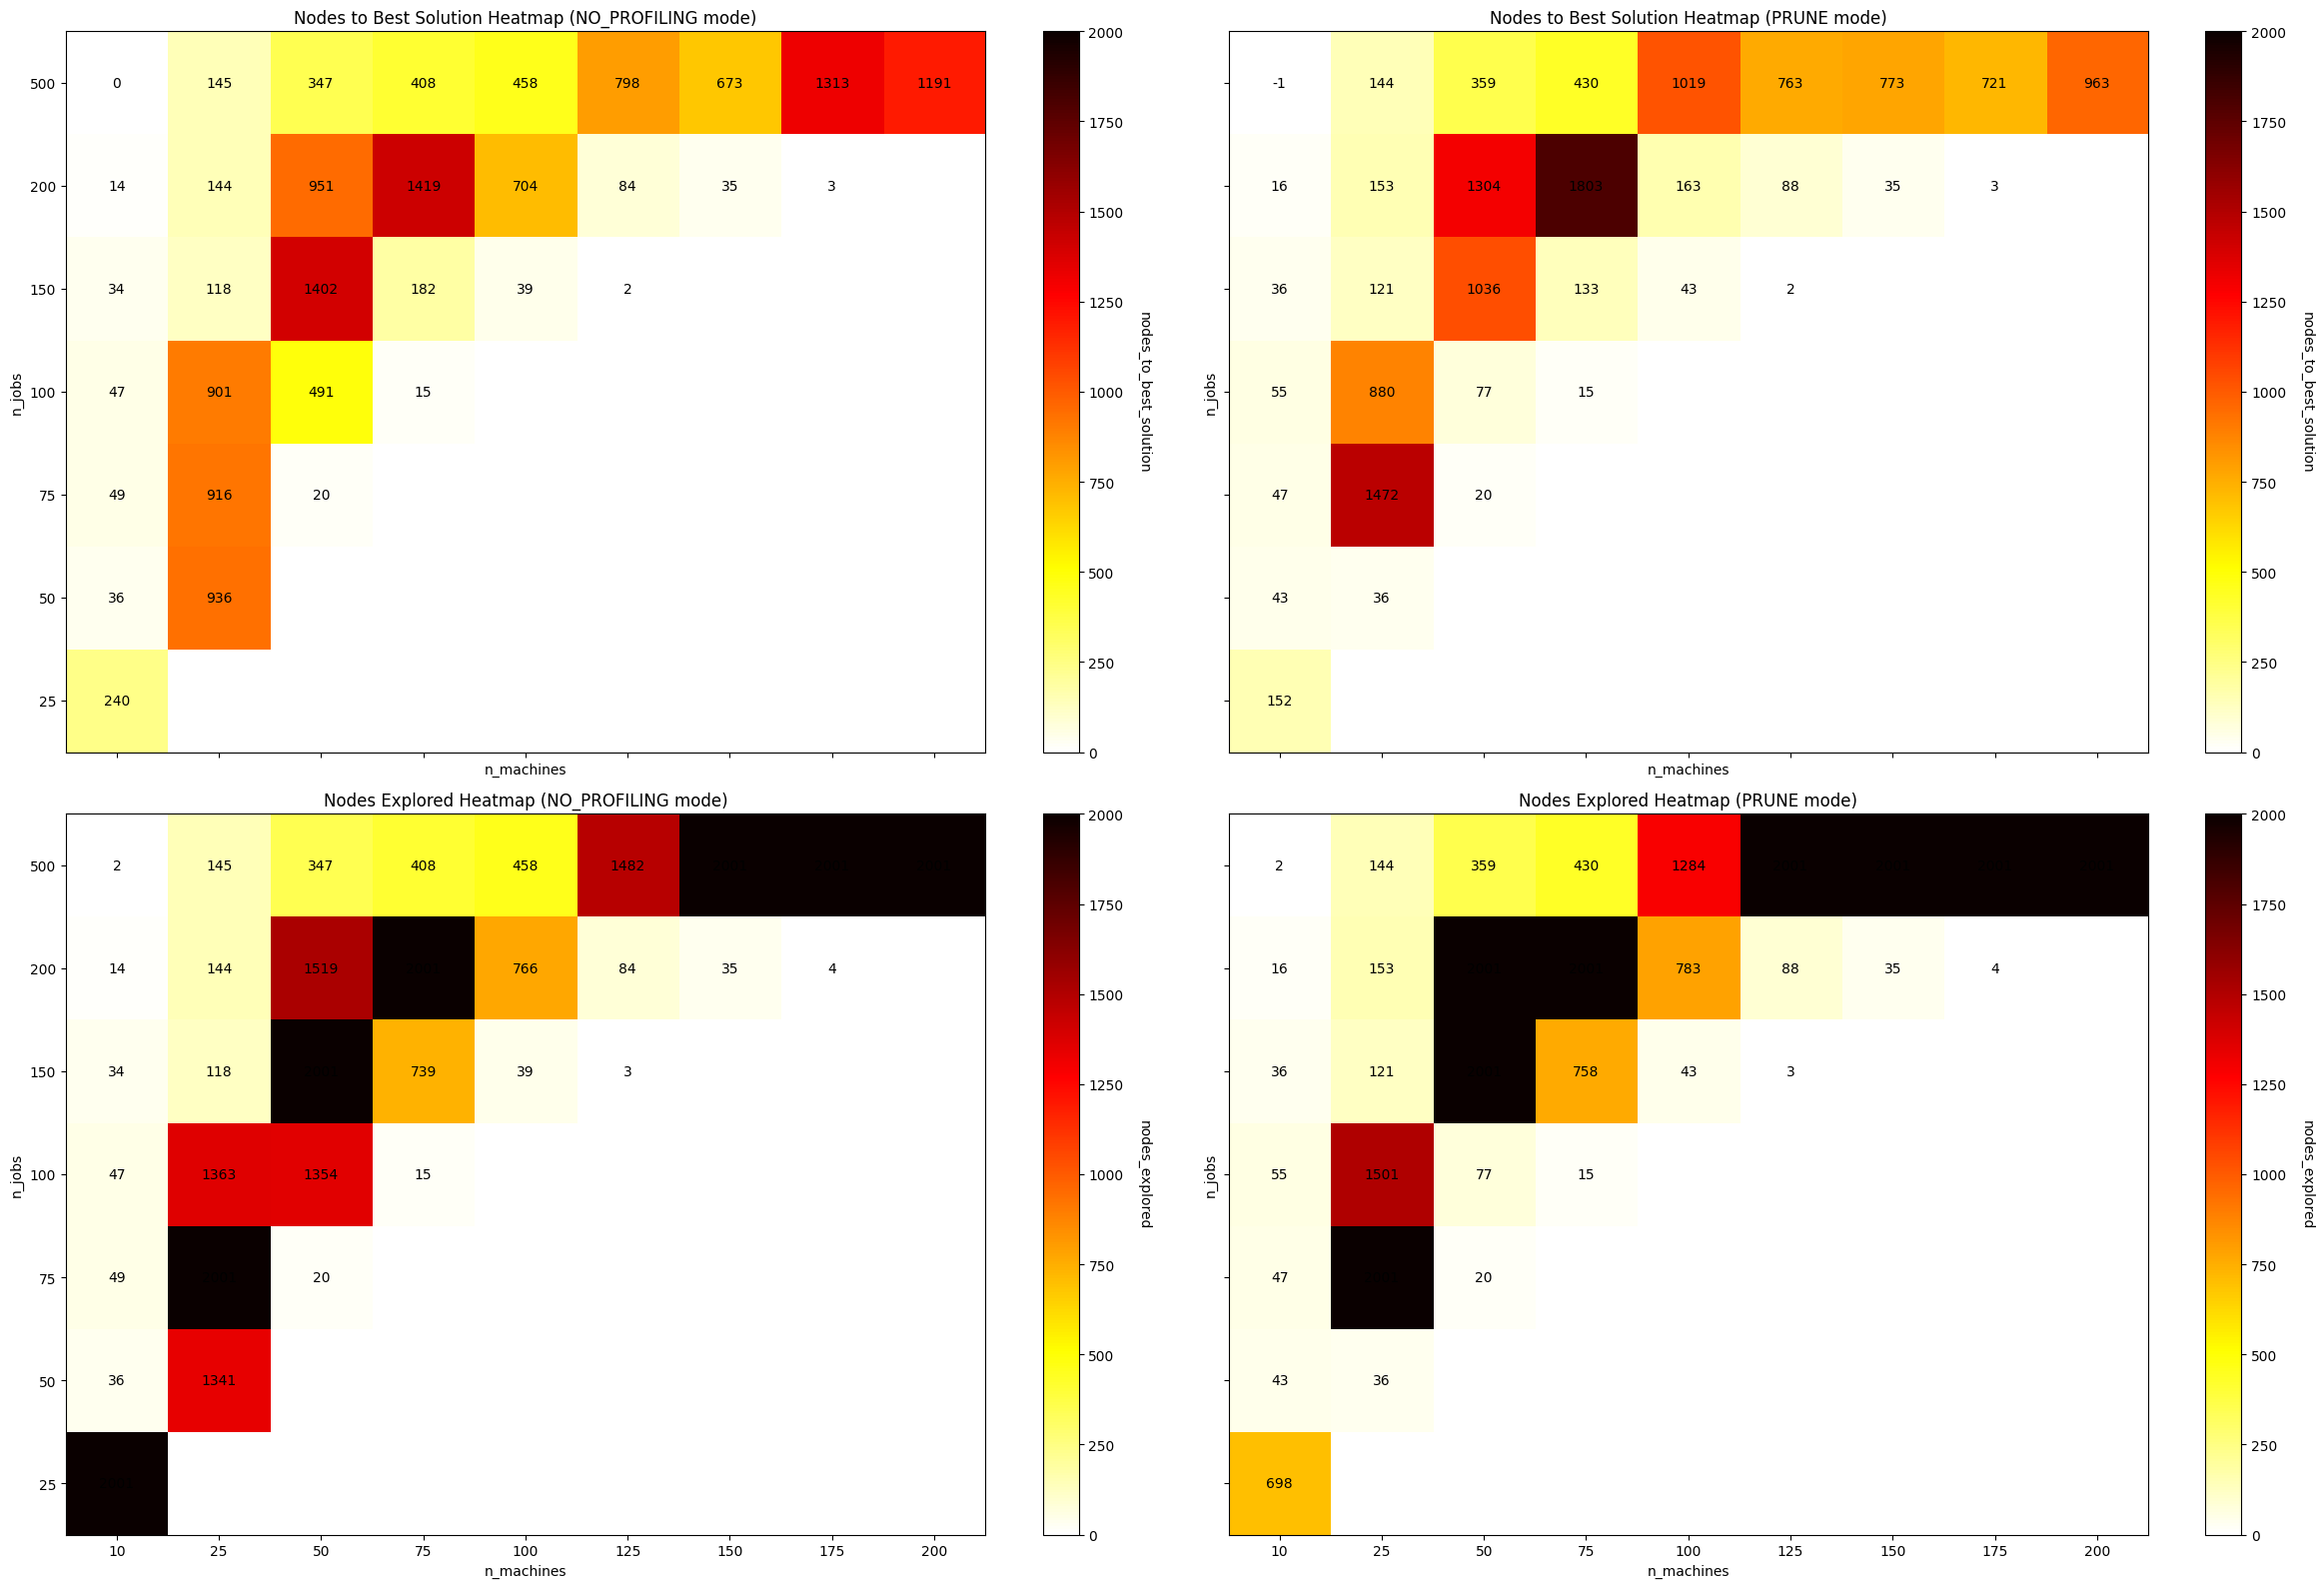

In [42]:
# Create subplots for each profiling_mode
profiling_modes = df_results['profiling_mode'].unique()
n_modes = len(profiling_modes)

# Calculate grid size for row-wise arrangement
n_cols = 2  # Number of columns for subplots
n_rows = (n_modes + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(2 * n_rows, n_cols, figsize=(12 * n_cols, 8 * n_rows * 2), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten axes for easy iteration

# First row: nodes_to_best_solution
for idx, (ax, mode) in enumerate(zip(axes[:n_modes], profiling_modes)):
    df_mode = df_results[df_results['profiling_mode'] == mode]

    # Create pivot table for heatmap
    heatmap_data = df_mode.pivot_table(
        values='nodes_to_best_solution',
        index='n_jobs',
        columns='n_machines',
        aggfunc='mean'
    )

    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='hot', aspect='auto')

    # Set ticks and labels
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.invert_yaxis()

    ax.set_xlabel('n_machines')
    ax.set_ylabel('n_jobs')
    ax.set_title(f'Nodes to Best Solution Heatmap ({mode} mode)')

    # Add colorbar
    im.set_clim(0, max_nodes)
    im.set_cmap(plt.cm.get_cmap('hot_r'))
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('nodes_to_best_solution', rotation=270, labelpad=20)

    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f'{int(value)}',
                        ha="center", va="center", color="black", fontsize=10)

# Second row: nodes_explored
for idx, (ax, mode) in enumerate(zip(axes[n_modes:], profiling_modes)):
    df_mode = df_results[df_results['profiling_mode'] == mode]

    # Create pivot table for heatmap
    heatmap_data = df_mode.pivot_table(
        values='nodes_explored',
        index='n_jobs',
        columns='n_machines',
        aggfunc='mean'
    )

    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='cool', aspect='auto')

    # Set ticks and labels
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.invert_yaxis()

    ax.set_xlabel('n_machines')
    ax.set_ylabel('n_jobs')
    ax.set_title(f'Nodes Explored Heatmap ({mode} mode)')

    # Add colorbar
    im.set_clim(0, max_nodes)
    im.set_cmap(plt.cm.get_cmap('hot_r'))
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('nodes_explored', rotation=270, labelpad=20)

    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f'{int(value)}',
                        ha="center", va="center", color="black", fontsize=10)

# Hide unused subplots
for ax in axes[2 * n_modes:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

C:\Users\Tiziano\AppData\Local\Temp\ipykernel_40420\1984975279.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im.set_cmap(plt.cm.get_cmap('hot_r'))
C:\Users\Tiziano\AppData\Local\Temp\ipykernel_40420\1984975279.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im.set_cmap(plt.cm.get_cmap('hot_r'))
C:\Users\Tiziano\AppData\Local\Temp\ipykernel_40420\1984975279.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly

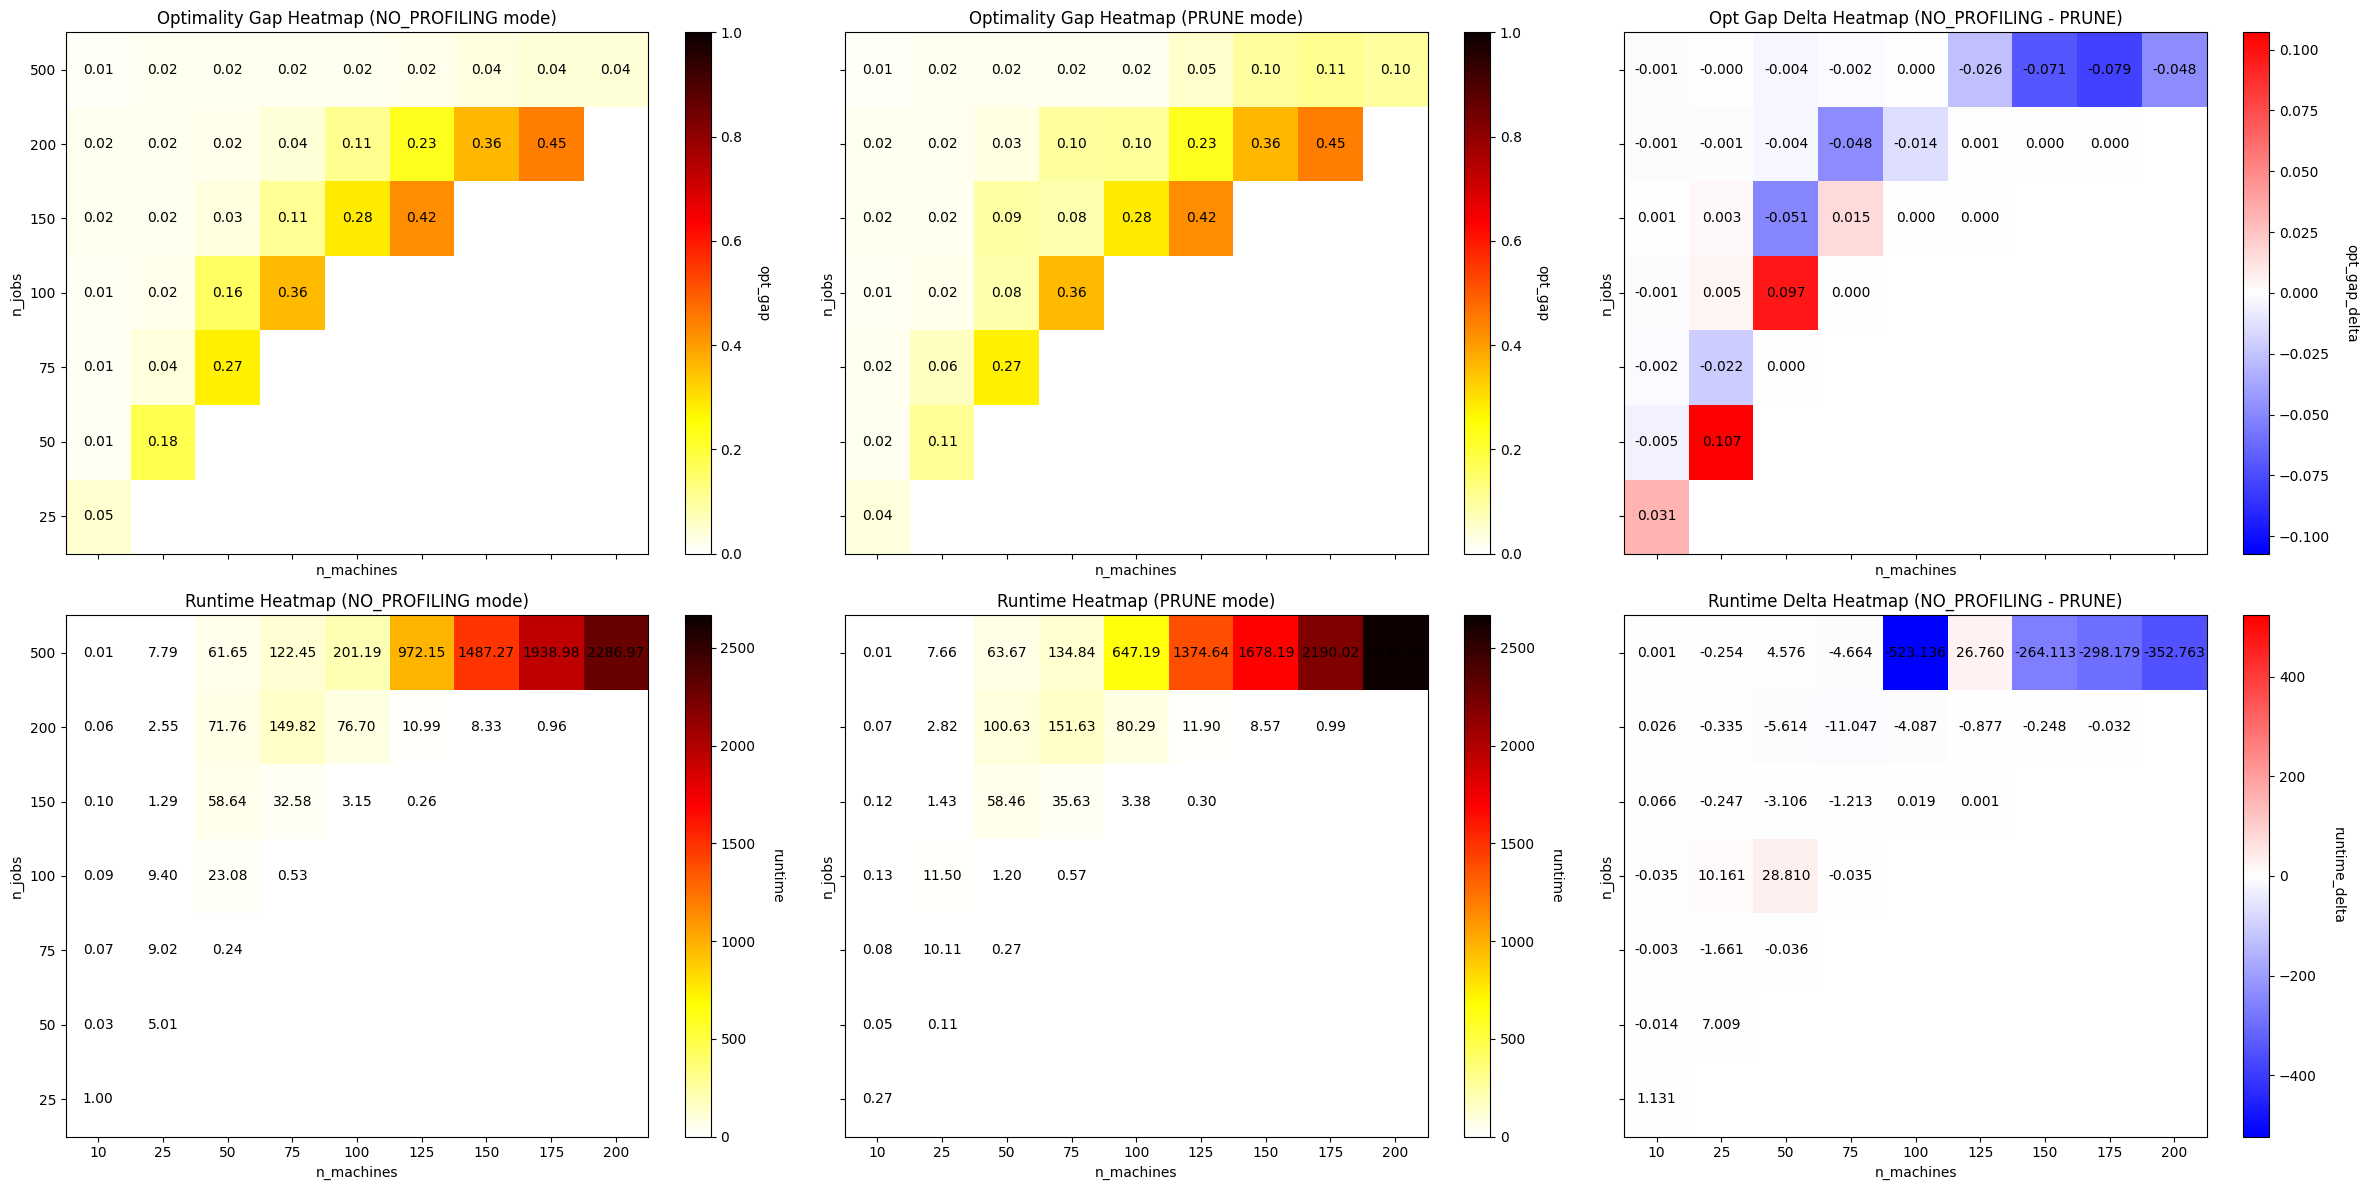

In [43]:
# Create subplots for each profiling_mode
profiling_modes = df_results['profiling_mode'].unique()
n_modes = len(profiling_modes)

# Calculate grid size for row-wise arrangement
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten axes for easy iteration

# First row: opt_gap
for idx, (ax, mode) in enumerate(zip(axes[0:2], profiling_modes)):
    df_mode = df_results[df_results['profiling_mode'] == mode]

    # Create pivot table for heatmap
    heatmap_data = df_mode.pivot_table(
        values='opt_gap',
        index='n_jobs',
        columns='n_machines',
        aggfunc='mean'
    )

    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='viridis', aspect='auto')

    # Set ticks and labels
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.invert_yaxis()

    ax.set_xlabel('n_machines')
    ax.set_ylabel('n_jobs')
    ax.set_title(f'Optimality Gap Heatmap ({mode} mode)')

    # Add colorbar
    im.set_clim(0, 1.0)
    im.set_cmap(plt.cm.get_cmap('hot_r'))
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('opt_gap', rotation=270, labelpad=20)

    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f'{value:.2f}',
                        ha="center", va="center", color="black", fontsize=10)

# First row: opt_gap delta
df_delta = df_results.groupby(['n_jobs', 'n_machines']).apply(
    lambda x: x[x['profiling_mode'] == 'NO_PROFILING']['opt_gap'].values[0] - 
              x[x['profiling_mode'] == 'PRUNE']['opt_gap'].values[0]
).reset_index(name='opt_gap')

ax = axes[2]
# Create pivot table for heatmap
heatmap_data = df_delta.pivot_table(
    values='opt_gap',
    index='n_jobs',
    columns='n_machines',
    aggfunc='mean'
)
    
# Create heatmap
im = ax.imshow(heatmap_data.values, cmap='bwr', aspect='auto')

# Set ticks and labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.invert_yaxis()

ax.set_xlabel('n_machines')
ax.set_ylabel('n_jobs')
ax.set_title(f'Opt Gap Delta Heatmap (NO_PROFILING - PRUNE)')

# Add colorbar
bound = np.nanmax(np.abs(heatmap_data.values))
im.set_clim(-bound, bound)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('opt_gap_delta', rotation=270, labelpad=20)

# Add text annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f'{value:.3f}',
                    ha="center", va="center", color="black", fontsize=10)


# Second row: runtime
max_runtime = df_results['runtime'].max()
for idx, (ax, mode) in enumerate(zip(axes[3:5], profiling_modes)):
    df_mode = df_results[df_results['profiling_mode'] == mode]

    # Create pivot table for heatmap
    heatmap_data = df_mode.pivot_table(
        values='runtime',
        index='n_jobs',
        columns='n_machines',
        aggfunc='mean'
    )

    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='plasma', aspect='auto')

    # Set ticks and labels
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.invert_yaxis()

    ax.set_xlabel('n_machines')
    ax.set_ylabel('n_jobs')
    ax.set_title(f'Runtime Heatmap ({mode} mode)')

    # Add colorbar
    im.set_clim(0, max_runtime)
    im.set_cmap(plt.cm.get_cmap('hot_r'))
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('runtime', rotation=270, labelpad=20)

    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f'{value:.2f}',
                        ha="center", va="center", color="black", fontsize=10)
                
# Second row: runtime delta
df_delta = df_results.groupby(['n_jobs', 'n_machines']).apply(
    lambda x: x[x['profiling_mode'] == 'NO_PROFILING']['runtime'].values[0] - 
              x[x['profiling_mode'] == 'PRUNE']['runtime'].values[0]
).reset_index(name='runtime')   
ax = axes[5]
# Create pivot table for heatmap
heatmap_data = df_delta.pivot_table(
    values='runtime',
    index='n_jobs',
    columns='n_machines',
    aggfunc='mean'
)
    
# Create heatmap
im = ax.imshow(heatmap_data.values, cmap='bwr', aspect='auto')

# Set ticks and labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.invert_yaxis()

ax.set_xlabel('n_machines')
ax.set_ylabel('n_jobs')
ax.set_title(f'Runtime Delta Heatmap (NO_PROFILING - PRUNE)')

# Add colorbar
bound = np.nanmax(np.abs(heatmap_data.values))
im.set_clim(-bound, bound)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('runtime_delta', rotation=270, labelpad=20)
# Add text annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f'{value:.3f}',
                    ha="center", va="center", color="black", fontsize=10)

# # Hide unused subplots
# for ax in axes[2 * n_modes:]:   
#     ax.axis('off')

plt.tight_layout()
plt.show()